# 10 — The Skimmer's Brake

This notebook formalizes a discussion that started with "is heavy Wax
tougher?" and ended somewhere better. The lore verdict (Coppermind,
notebook 09 era): tapping iron strengthens the body to *bear* the load but
grants no penetration resistance — and Elliott's challenge stands: hitting
the ground is bond-breaking, the same physics as penetration. Heavier atoms
do not buy tougher tissue. So why isn't book-Wax pink mist?

Because of something the canon momentum rule forces, which this engine has
quietly implemented since notebook 03: **iron feruchemy is an energy
pump.** Kinetic energy is $KE = p^2 / 2m$, and momentum $p$ survives a mass
change — so tapping to double mass while moving instantly *deletes half
your kinetic energy* from the physical world, and storing while moving
*creates* energy from nowhere. The standard cosmere reading: Investiture
pays the difference. (The momentum rule is verified WoB; the energy
consequence is arithmetic; naming the payer "Investiture" is
interpretation, flagged as such.)

The tactical consequence is a complete landing doctrine, measured below:
**store early for speed, tap late to live, never tap at the top.**

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt

from sim import Body, World, IronFeruchemy, GRAVITY_M_PER_S2

APEX_HEIGHT_M = 18.9  # the coin-launch apex from notebooks 02-03

## Experiment A — the pump, watched live

A Skimmer falls. Mid-fall he taps to double mass (the brake bites: velocity
halves, half his kinetic energy vanishes), then stores down to half base
mass (the pump runs backward: the magic *injects* energy and he rockets).
We plot total kinetic energy through both events — the staircase is energy
entering and leaving the physical world.

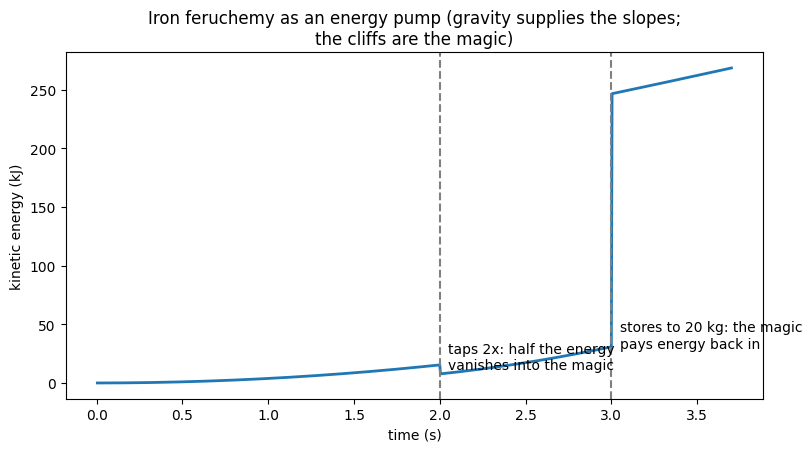

In [2]:
world = World()
skimmer = world.add_body(Body("skimmer", 80, (0, 300)))
ironmind = world.add_power(IronFeruchemy(skimmer, initial_reserve_kg_seconds=600))

times, kinetic_energy = [], []
def record_for(duration):
    for _ in range(int(duration / world.dt_seconds)):
        world.step()
        times.append(world.time_seconds)
        kinetic_energy.append(0.5 * skimmer.mass_kg * skimmer.velocity[1] ** 2)

record_for(2.0)
ironmind.tap(1.0)      # mass 80 -> 160: the brake
record_for(1.0)
ironmind.store(0.75)   # mass 160 -> 20: the pump runs backward, hard
record_for(0.7)

figure, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(times, np.array(kinetic_energy) / 1000, linewidth=2)
ax.axvline(2.0, color="gray", linestyle="--")
ax.annotate("taps 2x: half the energy\nvanishes into the magic", (2.05, 12))
ax.axvline(3.0, color="gray", linestyle="--")
ax.annotate("stores to 20 kg: the magic\npays energy back in", (3.05, 30))
ax.set_xlabel("time (s)")
ax.set_ylabel("kinetic energy (kJ)")
ax.set_title("Iron feruchemy as an energy pump (gravity supplies the slopes;\nthe cliffs are the magic)")
plt.show()

## Experiment B — when to pull the brake: the tap-altitude sweep

Falling from the 18.9 m coin-launch apex, the Skimmer taps 2× at some
altitude — the one knob. Measured at impact: the kinetic energy his own
tissues must survive, and the momentum the ground must stop.

Paper prediction: tap at the apex and the brake grabs nothing (v = 0 means
p = 0) — he lands with *double* baseline energy. Tap at the ground and the
brake eats fully half. In between, linear. The baseline 80 kg landing
(14.6 kJ) should sit partway up the line: there exists a tap altitude below
which a HEAVY landing is gentler on the Skimmer than a light one.

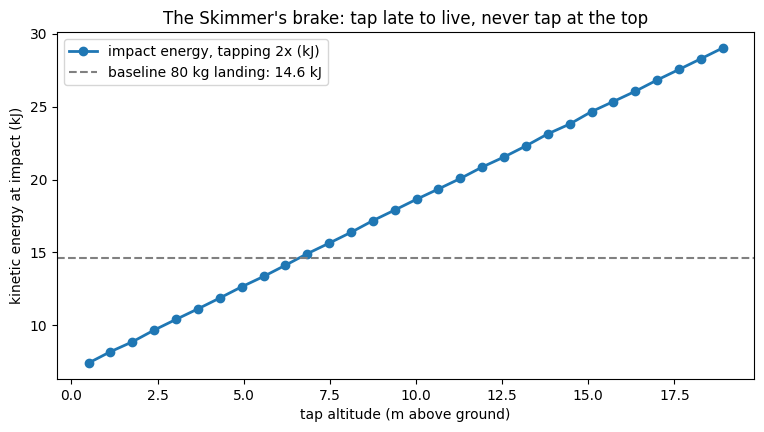

below ~6.8 m of tap altitude, the HEAVY landing is gentler on the
Skimmer than the plain light landing — while carrying far more momentum.
extremes: tap at 0.5 m -> 7.4 kJ; tap at apex -> 29.0 kJ


In [3]:
def fall_and_tap(tap_altitude_m):
    world = World()
    skimmer = world.add_body(Body("skimmer", 80, (0, APEX_HEIGHT_M)))
    ironmind = world.add_power(IronFeruchemy(skimmer, initial_reserve_kg_seconds=600))
    while not skimmer.on_ground:
        if skimmer.position[1] <= tap_altitude_m and ironmind.tap_fraction == 0:
            ironmind.tap(1.0)
        impact_mass, impact_speed = skimmer.mass_kg, abs(skimmer.velocity[1])
        world.step()
    return (0.5 * impact_mass * impact_speed**2 / 1000,  # kJ through his bones
            impact_mass * impact_speed)                  # momentum into the ground

tap_altitudes = np.linspace(0.5, APEX_HEIGHT_M, 30)
energies, momenta = zip(*[fall_and_tap(h) for h in tap_altitudes])
baseline_energy = 0.5 * 80 * (2 * GRAVITY_M_PER_S2 * (APEX_HEIGHT_M - 0.3)) / 1000

figure, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(tap_altitudes, energies, "o-", linewidth=2, label="impact energy, tapping 2x (kJ)")
ax.axhline(baseline_energy, color="gray", linestyle="--",
           label=f"baseline 80 kg landing: {baseline_energy:.1f} kJ")
ax.set_xlabel("tap altitude (m above ground)")
ax.set_ylabel("kinetic energy at impact (kJ)")
ax.set_title("The Skimmer's brake: tap late to live, never tap at the top")
ax.legend()
plt.show()

crossover = tap_altitudes[np.argmax(np.array(energies) > baseline_energy)]
print(f"below ~{crossover:.1f} m of tap altitude, the HEAVY landing is gentler on the")
print(f"Skimmer than the plain light landing — while carrying far more momentum.")
print(f"extremes: tap at 0.5 m -> {energies[0]:.1f} kJ; tap at apex -> {energies[-1]:.1f} kJ")

## Experiment C — how hard to pull it: the tap-magnitude sweep

Brake at 1 m altitude, sweeping how hard he taps (final mass 80 to 400 kg).
Paper: energy after the tap scales by old/new mass, so impact energy should
fall like 1/mass while impact momentum *rises* — the harder and later the
tap, the gentler the landing on him and the worse for whatever he lands on.

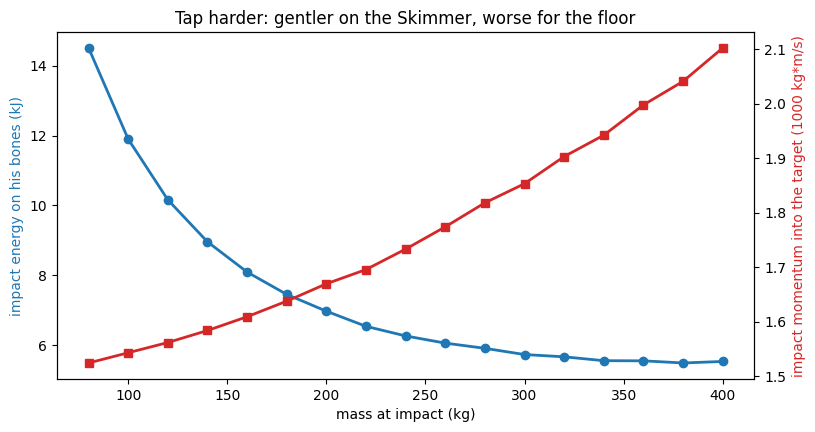

untapped: 14.5 kJ on his bones | tapped to 400 kg: 5.5 kJ
...while his momentum grows 1.4x. The meteor that lands softly.


In [4]:
def fall_and_tap_hard(tap_fraction):
    world = World()
    skimmer = world.add_body(Body("skimmer", 80, (0, APEX_HEIGHT_M)))
    ironmind = world.add_power(IronFeruchemy(skimmer, initial_reserve_kg_seconds=3000))
    while not skimmer.on_ground:
        if skimmer.position[1] <= 1.0 and ironmind.tap_fraction == 0 and tap_fraction > 0:
            ironmind.tap(tap_fraction)
        impact_mass, impact_speed = skimmer.mass_kg, abs(skimmer.velocity[1])
        world.step()
    return (0.5 * impact_mass * impact_speed**2 / 1000, impact_mass * impact_speed / 1000)

tap_fractions = np.linspace(0, 4, 17)  # final mass 80..400 kg
energies, momenta = zip(*[fall_and_tap_hard(f) for f in tap_fractions])
final_masses = 80 * (1 + tap_fractions)

figure, ax_energy = plt.subplots(figsize=(9, 4.5))
ax_energy.plot(final_masses, energies, "o-", color="tab:blue", linewidth=2)
ax_energy.set_xlabel("mass at impact (kg)")
ax_energy.set_ylabel("impact energy on his bones (kJ)", color="tab:blue")
ax_momentum = ax_energy.twinx()
ax_momentum.plot(final_masses, momenta, "s-", color="tab:red", linewidth=2)
ax_momentum.set_ylabel("impact momentum into the target (1000 kg*m/s)", color="tab:red")
ax_energy.set_title("Tap harder: gentler on the Skimmer, worse for the floor")
plt.show()

print(f"untapped: {energies[0]:.1f} kJ on his bones | tapped to 400 kg: {energies[-1]:.1f} kJ")
print(f"...while his momentum grows {momenta[-1]/momenta[0]:.1f}x. The meteor that lands softly.")

## Findings

1. **The energy pump is real and exact**: tap 2× while moving and half the
   kinetic energy leaves the physical world on that tick; store and it
   pours back in (probe-verified to floating-point). Gravity draws the
   slopes; the magic draws the cliffs.
2. **The landing doctrine is measured**: impact energy is linear in tap
   altitude, from half-baseline (tap at the ground) to double-baseline
   (tap at the apex), with a crossover altitude below which the heavy
   landing is *gentler on the Skimmer than a light one*. Never tap at the
   top.
3. **Tap harder, land softer, hit harder**: impact energy on his own bones
   falls like 1/mass while delivered momentum climbs. A maximally late,
   maximally hard tap is simultaneously the safest landing for Wax and the
   worst event for the floor — the meteor that lands softly. This, not
   magical toughness, is how a physics-honest Skimmer survives his own
   signature move.
4. **What would still require a toughness grant**: only an apex-heavy crash
   walked off. Whether book-Wax ever does that is the open lore check in
   IDEAS.md; until a scene demands it, the engine needs no patch.
5. **Corollary for fights**: a Skimmer's iron dial is also an emergency
   brake against *thrown* velocity — pushed off a roof by a Coinshot, tap
   hard and you land survivably heavy. The counter to one metal is another
   metal, which is the most Mistborn sentence the lab has produced yet.